# 🦺 Real-Time Worker Detection
### Computer Vision with YOLOv4-tiny + OpenCV DNN



In [1]:
## Step 1 — Install / Verify Libraries
import subprocess
import sys

packages = {
    'opencv-python': 'cv2',
    'numpy': 'numpy',
    'requests': 'requests'
}

for package, module_name in packages.items():
    try:
        __import__(module_name)
        print(f'✅ {package} already installed')
    except ImportError:
        print(f'📦 Installing {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f'✅ {package} installed')

print('\n✅ All libraries ready!')


📦 Installing opencv-python...
✅ opencv-python installed
✅ numpy already installed
✅ requests already installed

✅ All libraries ready!


In [2]:
## Step 2 — Download YOLOv4-tiny Model
import urllib.request
from pathlib import Path

MODEL_DIR = Path("yolo_model")
MODEL_DIR.mkdir(exist_ok=True)

FILES = {
    'yolov4-tiny.cfg':
        'https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4-tiny.cfg',
    'coco.names':
        'https://raw.githubusercontent.com/AlexeyAB/darknet/master/data/coco.names',
    'yolov4-tiny.weights':
        'https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov4-tiny.weights'
}

for filename, url in FILES.items():
    dest = MODEL_DIR / filename

    if dest.exists() and dest.stat().st_size > 1000:
        print(f'✅ {filename} already exists')
        continue

    print(f'⬇️ Downloading {filename}...')
    try:
        urllib.request.urlretrieve(url, dest)
        print(f'✅ Saved: {dest}')
    except Exception as e:
        print(f'❌ Failed downloading {filename}: {e}')

print('\n✅ Model files ready!')


⬇️ Downloading yolov4-tiny.cfg...
✅ Saved: yolo_model\yolov4-tiny.cfg
⬇️ Downloading coco.names...
✅ Saved: yolo_model\coco.names
⬇️ Downloading yolov4-tiny.weights...
✅ Saved: yolo_model\yolov4-tiny.weights

✅ Model files ready!


In [3]:
## Step 3 — Load YOLO Model
import cv2
import numpy as np
from pathlib import Path

MODEL_DIR = Path("yolo_model")

with open(MODEL_DIR / 'coco.names', 'r') as f:
    CLASSES = f.read().strip().split('\n')

print(f'📋 Loaded {len(CLASSES)} classes')

net = cv2.dnn.readNet(
    str(MODEL_DIR / 'yolov4-tiny.weights'),
    str(MODEL_DIR / 'yolov4-tiny.cfg')
)

net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

layer_names = net.getLayerNames()

# OpenCV compatibility fix
unconnected = net.getUnconnectedOutLayers()

try:
    output_layers = [layer_names[i - 1] for i in unconnected.flatten()]
except:
    output_layers = [layer_names[i[0] - 1] for i in unconnected]

print('✅ YOLOv4-tiny loaded successfully')
print('Output layers:', output_layers)


📋 Loaded 80 classes
✅ YOLOv4-tiny loaded successfully
Output layers: ['yolo_30', 'yolo_37']


In [4]:
## Step 4 — Helper Functions
import time

WORKER_COLOR = (0, 220, 100)
OTHER_COLOR = (80, 80, 200)

CONF_THRESHOLD = 0.45
NMS_THRESHOLD = 0.40

def detect_objects(frame, net, output_layers,
                   conf_thresh=CONF_THRESHOLD,
                   nms_thresh=NMS_THRESHOLD):

    H, W = frame.shape[:2]

    blob = cv2.dnn.blobFromImage(
        frame,
        1/255.0,
        (416, 416),
        swapRB=True,
        crop=False
    )

    net.setInput(blob)
    outputs = net.forward(output_layers)

    boxes = []
    confidences = []
    class_ids = []

    for output in outputs:
        for det in output:

            scores = det[5:]
            class_id = int(np.argmax(scores))
            confidence = float(scores[class_id])

            if confidence < conf_thresh:
                continue

            cx, cy = int(det[0] * W), int(det[1] * H)
            w, h = int(det[2] * W), int(det[3] * H)

            x = int(cx - w / 2)
            y = int(cy - h / 2)

            boxes.append([x, y, w, h])
            confidences.append(confidence)
            class_ids.append(class_id)

    indices = cv2.dnn.NMSBoxes(
        boxes,
        confidences,
        conf_thresh,
        nms_thresh
    )

    results = []

    if len(indices) > 0:
        for i in indices.flatten():
            results.append({
                'box': boxes[i],
                'confidence': confidences[i],
                'class_id': class_ids[i],
                'label': CLASSES[class_ids[i]]
            })

    return results


def draw_detections(frame, detections, show_all=False):

    worker_count = 0

    for det in detections:

        x, y, w, h = det['box']
        label = det['label']
        conf = det['confidence']

        is_worker = label == 'person'

        if not show_all and not is_worker:
            continue

        color = WORKER_COLOR if is_worker else OTHER_COLOR

        if is_worker:
            worker_count += 1

        cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)

        text = f"{label.upper()} {conf:.0%}"

        cv2.putText(
            frame,
            text,
            (x, max(20, y - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    return frame, worker_count


print('✅ Helper functions ready!')


✅ Helper functions ready!


In [5]:
## Step 5 — Real-Time Detection
import cv2
import time
from pathlib import Path
from datetime import datetime

CAMERA_INDEX = 0
SHOW_ALL_OBJ = False

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print('❌ Could not open camera.')
    print('Try changing CAMERA_INDEX to 1 or 2.')
else:

    print('📷 Camera opened successfully')
    print('Press Q to quit')

    screenshot_dir = Path('screenshots')
    screenshot_dir.mkdir(exist_ok=True)

    fps_counter = 0
    fps_display = 0
    t0 = time.time()

    while True:

        ret, frame = cap.read()

        if not ret:
            print('⚠️ Failed to read frame')
            break

        detections = detect_objects(frame, net, output_layers)

        frame, worker_count = draw_detections(
            frame,
            detections,
            show_all=SHOW_ALL_OBJ
        )

        fps_counter += 1
        elapsed = time.time() - t0

        if elapsed >= 1:
            fps_display = fps_counter / elapsed
            fps_counter = 0
            t0 = time.time()

        cv2.putText(
            frame,
            f'FPS: {fps_display:.1f}',
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

        cv2.putText(
            frame,
            f'Workers: {worker_count}',
            (10, 65),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,0),
            2
        )

        cv2.imshow('Worker Detection', frame)

        key = cv2.waitKey(1) & 0xFF

        if key in [ord('q'), ord('Q')]:
            break

        elif key in [ord('a'), ord('A')]:
            SHOW_ALL_OBJ = not SHOW_ALL_OBJ
            print('Toggle all objects:', SHOW_ALL_OBJ)

        elif key in [ord('s'), ord('S')]:
            ts = datetime.now().strftime('%Y%m%d_%H%M%S')
            path = screenshot_dir / f'screenshot_{ts}.jpg'
            cv2.imwrite(str(path), frame)
            print(f'📸 Saved: {path}')

    cap.release()
    cv2.destroyAllWindows()

    print('✅ Session ended')


📷 Camera opened successfully
Press Q to quit
✅ Session ended


## Step 6 — Static Image Test

Use this if your webcam does not work.


✅ Workers detected: 3
✅ Total detections: 4


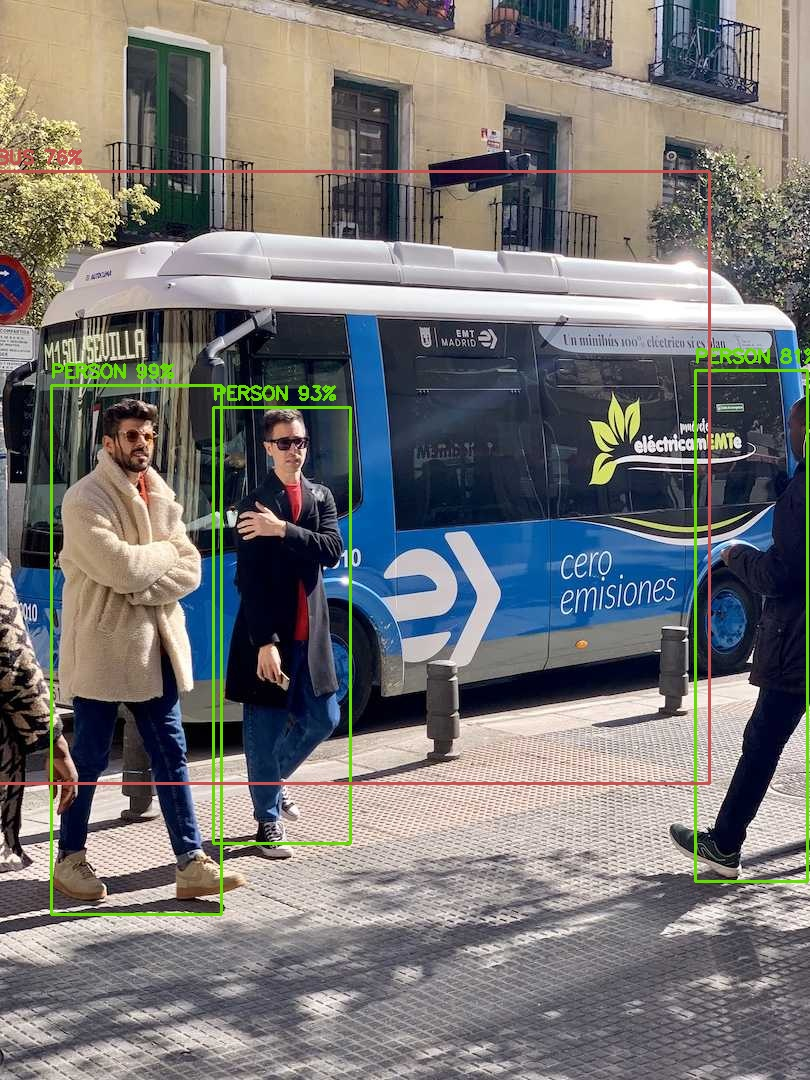

In [6]:
## Static Image Test
import cv2
import urllib.request
from IPython.display import display, Image

sample_url = 'https://ultralytics.com/images/bus.jpg'
sample_path = 'sample.jpg'

urllib.request.urlretrieve(sample_url, sample_path)

img = cv2.imread(sample_path)

if img is None:
    print('❌ Failed loading sample image')
else:

    detections = detect_objects(
        img,
        net,
        output_layers,
        conf_thresh=0.35
    )

    out, wc = draw_detections(
        img,
        detections,
        show_all=True
    )

    out_path = 'sample_output.jpg'
    cv2.imwrite(out_path, out)

    print(f'✅ Workers detected: {wc}')
    print(f'✅ Total detections: {len(detections)}')

    display(Image(filename=out_path))


## Notes

| Setting | Purpose |
|---|---|
| CAMERA_INDEX | Change if webcam fails |
| CONF_THRESHOLD | Lower = more detections |
| SHOW_ALL_OBJ | Show all COCO classes |

Built with:
- OpenCV DNN
- YOLOv4-tiny
- CPU-only inference
